In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Load dataset
a = pd.read_csv("loan approval.csv")
print(a)

      Loan_ID Gender Married Dependents     Education Self_Employed  \
0    LP001015   Male     Yes          0      Graduate            No   
1    LP001022   Male     Yes          1      Graduate            No   
2    LP001031   Male     Yes          2      Graduate            No   
3    LP001035   Male     Yes          2      Graduate            No   
4    LP001051   Male      No          0  Not Graduate            No   
..        ...    ...     ...        ...           ...           ...   
362  LP002971   Male     Yes         3+  Not Graduate           Yes   
363  LP002975   Male     Yes          0      Graduate            No   
364  LP002980   Male      No          0      Graduate            No   
365  LP002986   Male     Yes          0      Graduate            No   
366  LP002989   Male      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5720                  0       110.0             360.0   
1

In [30]:
a.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [31]:
a.isnull().sum()


,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [32]:
a.dropna(inplace=True)

In [33]:
a.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [34]:
a.duplicated().sum()

np.int64(0)

In [35]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 289 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            289 non-null    object 
 1   Gender             289 non-null    object 
 2   Married            289 non-null    object 
 3   Dependents         289 non-null    object 
 4   Education          289 non-null    object 
 5   Self_Employed      289 non-null    object 
 6   ApplicantIncome    289 non-null    int64  
 7   CoapplicantIncome  289 non-null    int64  
 8   LoanAmount         289 non-null    float64
 9   Loan_Amount_Term   289 non-null    float64
 10  Credit_History     289 non-null    float64
 11  Property_Area      289 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 29.4+ KB


In [36]:
#Label Encoding
le = LabelEncoder()
cols=['Loan_ID','Gender','Married','Dependents','Education','Self_Employed','Property_Area']
for col in cols:
    a[col]=le.fit_transform(a[col])




In [37]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 289 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            289 non-null    int64  
 1   Gender             289 non-null    int64  
 2   Married            289 non-null    int64  
 3   Dependents         289 non-null    int64  
 4   Education          289 non-null    int64  
 5   Self_Employed      289 non-null    int64  
 6   ApplicantIncome    289 non-null    int64  
 7   CoapplicantIncome  289 non-null    int64  
 8   LoanAmount         289 non-null    float64
 9   Loan_Amount_Term   289 non-null    float64
 10  Credit_History     289 non-null    float64
 11  Property_Area      289 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 29.4 KB


In [38]:
#Feature extraction
x=a.drop('Credit_History',axis=1)
y=a['Credit_History']

In [39]:
#Train - Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
# Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



Logistic Regression
Accuracy: 77.59%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        13
         1.0       0.78      1.00      0.87        45

    accuracy                           0.78        58
   macro avg       0.39      0.50      0.44        58
weighted avg       0.60      0.78      0.68        58



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


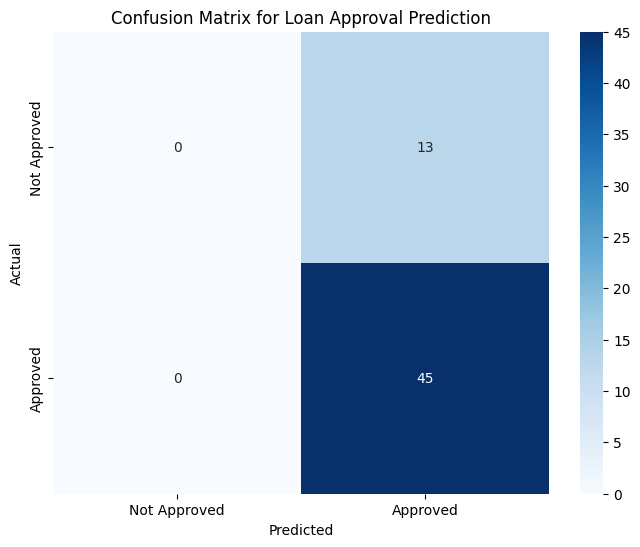

In [41]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(x_train, y_train)

y_pred_lr = model_lr.predict(x_test)

print("Logistic Regression")
accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Loan Approval Prediction')
plt.show()

KNN
Accuracy: 79.31%
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.08      0.14        13
         1.0       0.79      1.00      0.88        45

    accuracy                           0.79        58
   macro avg       0.89      0.54      0.51        58
weighted avg       0.84      0.79      0.72        58



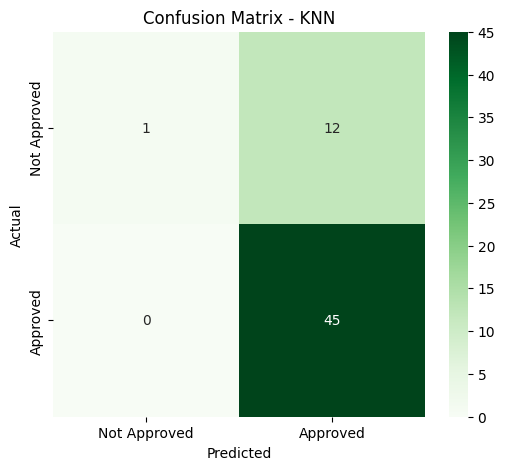

In [42]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)

y_pred_knn = model_knn.predict(x_test)

print("KNN")
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM
Accuracy: 77.59%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        13
         1.0       0.78      1.00      0.87        45

    accuracy                           0.78        58
   macro avg       0.39      0.50      0.44        58
weighted avg       0.60      0.78      0.68        58



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


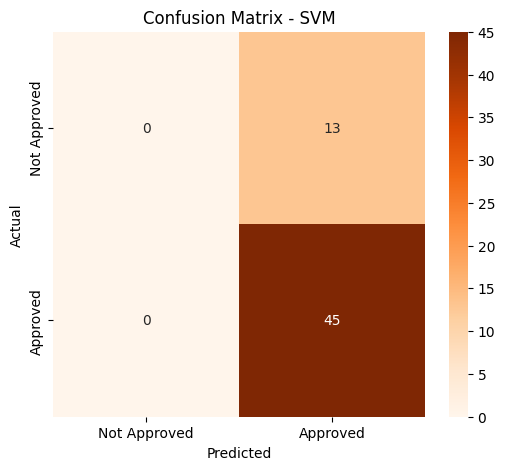

In [43]:
#SVM
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(x_train, y_train)

y_pred_svm = model_svm.predict(x_test)

print("SVM")
accuracy = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NAIVE BAYES
Accuracy: 72.41%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.33      0.23      0.27        13
         1.0       0.80      0.87      0.83        45

    accuracy                           0.72        58
   macro avg       0.56      0.55      0.55        58
weighted avg       0.69      0.72      0.70        58



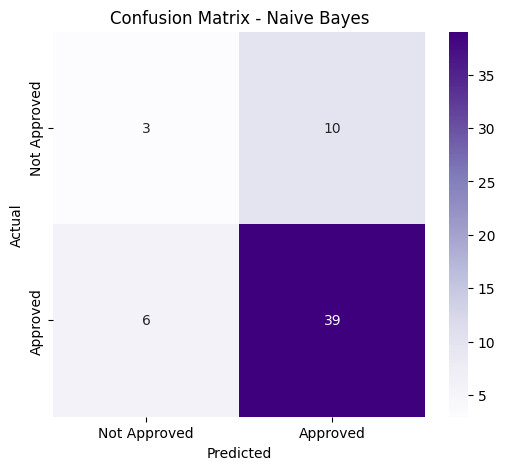

In [44]:
#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(x_train, y_train)

y_pred_nb = model_nb.predict(x_test)

print("NAIVE BAYES")
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DECISION TREE
Accuracy: 74.14%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.38      0.23      0.29        13
         1.0       0.80      0.89      0.84        45

    accuracy                           0.74        58
   macro avg       0.59      0.56      0.56        58
weighted avg       0.70      0.74      0.72        58



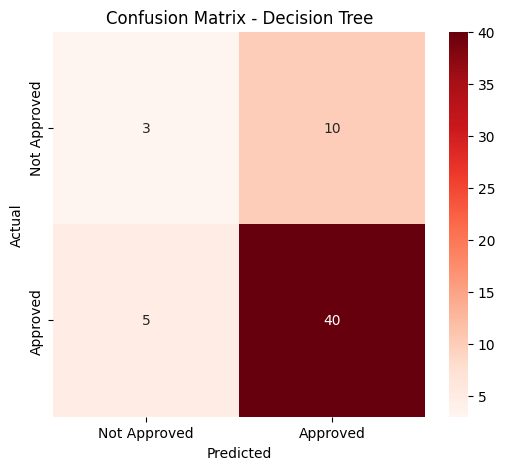

In [45]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train, y_train)

y_pred_dt = model_dt.predict(x_test)

print("DECISION TREE")
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RANDOM FOREST
Accuracy: 75.86%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        13
         1.0       0.77      0.98      0.86        45

    accuracy                           0.76        58
   macro avg       0.39      0.49      0.43        58
weighted avg       0.60      0.76      0.67        58



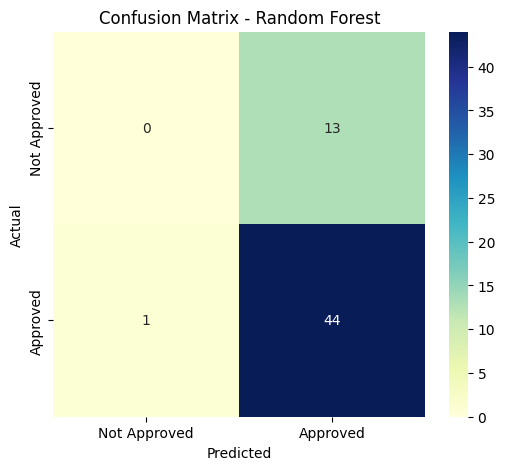

In [46]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

print("RANDOM FOREST")
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

GRADIENT BOOSTING
Accuracy: 77.59%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.50      0.15      0.24        13
         1.0       0.80      0.96      0.87        45

    accuracy                           0.78        58
   macro avg       0.65      0.55      0.55        58
weighted avg       0.73      0.78      0.73        58



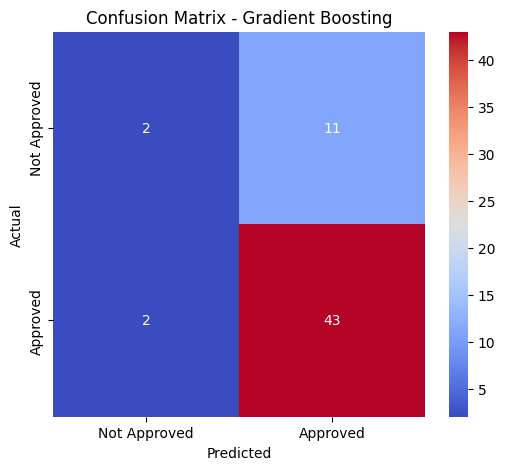

In [47]:
#
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()
model_gb.fit(x_train, y_train)

y_pred_gb = model_gb.predict(x_test)

print("GRADIENT BOOSTING")
accuracy = accuracy_score(y_test, y_pred_gb)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()